<a href="https://colab.research.google.com/github/sparkyyyhd-bu/bu-rise-music/blob/social-media/explore_social_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploring `songs_with_social_features.parquet`

This notebook shows how to work with the final analysis table produced by the social pipeline:

- **`data/processed/songs_with_social_features.parquet`** — one row per song (101,939 rows, one per SpotGen `track_id`), with all social features already joined.
- **`data/interim/song_post_matches.parquet`** — the post-level detail behind those features: every Reddit post matched to a song, with its confidence score and accept/review/reject decision.

**A note on terminology:** the archive collection stores Reddit *submissions* (posts), not comment threads. Each post carries a `num_comments` count, which is what the `n_comments_*` features aggregate. When this notebook says "comments/discussion for a song," it means the matched posts and their engagement counts.

All data here is genuinely collected (`any_simulated` is False everywhere); accepted matches were audited at ~93% precision.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# project root = parent of notebooks/ ; adjust if you run from elsewhere
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

songs = pd.read_parquet(ROOT / "/content/drive/MyDrive/music/data/processed/songs_with_social_features.parquet")
posts = pd.read_parquet(ROOT / "/content/drive/MyDrive/music/data/interim/song_post_matches.parquet")

print(f"songs table: {songs.shape[0]:,} rows x {songs.shape[1]} cols")
print(f"posts table: {posts.shape[0]:,} rows ({(posts.decision == 'accept').sum():,} accepted)")
songs.head(3)

songs table: 101,939 rows x 76 cols
posts table: 1,305,243 rows (634,745 accepted)


,track_id,song_key,raw_title,base_title,norm_title,featured,version_tags,is_alt_version,primary_artist,norm_artist,...,n_posts_full,peak_week_full,peak_intensity_full,days_to_peak_full,n_spikes_full,decay_ratio_full,persistence_full,recent_share_full,growth_rate_wk1_wk4_full,sentiment_backend
0,5qljLQuKnNJf4F4vfxQB0V,blood|jesse markin,Blood,Blood,blood,,,False,Jesse Markin,jesse markin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fallback_lexicon
1,3VAX2MJdmdqARLSU5hPMpm,the ugly duckling|favorite kids stories,The Ugly Duckling,The Ugly Duckling,the ugly duckling,,,False,Favorite Kids Stories,favorite kids stories,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fallback_lexicon
2,1L3YAhsEMrGVvCgDXj2TYn,jimmy launches his own range of greetings card...,Jimmy Launches His Own Range Of Greetings Cards,Jimmy Launches His Own Range Of Greetings Cards,jimmy launches his own range of greetings cards,,,False,Jimmy Carr,jimmy carr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fallback_lexicon


## 1. Understanding the columns

The songs table has four groups of columns:

| Group | Columns | Meaning |
|---|---|---|
| **Identity** | `track_id`, `base_title`, `primary_artist`, `all_artists`, `album_name`, ... | Who/what the song is (from SpotGen) |
| **Outcomes** | `popularity` (Spotify 0–100, snapshot 2019-04-26), `release_date` | What we model |
| **Windowed social features** | `n_posts_30d`, `total_score_30d`, `sent_mean_30d`, ... for 7d/30d/90d/365d | Reddit activity inside `[release, release + window)` — **leakage-safe**: only counts posts before the popularity snapshot |
| **Trajectory features** | `n_posts_full`, `peak_week_full`, `decay_ratio_full`, `persistence_full`, ... | Whole-history shape of attention — **descriptive only** (they see post-snapshot data, so never use them to predict the 2019 popularity) |

Two flags matter for any analysis:
- `windows_valid` — True only when the release date has day precision, so the windowed features are trustworthy (93,109 songs).
- `any_simulated` — provenance guard; must be False (it is, everywhere).

In [ ]:
assert not songs["any_simulated"].any(), "table should contain no simulated records"

covered = songs["n_posts_full"].fillna(0) > 0
print(f"songs with >= 1 accepted Reddit mention: {covered.sum():,} ({covered.mean():.1%})")
print(f"songs with valid observation windows:   {songs['windows_valid'].sum():,}")

songs.filter(regex="_30d$|_full$").describe().T.round(2)

songs with >= 1 accepted Reddit mention: 32,921 (32.3%)
songs with valid observation windows:   93,109


,count,mean,std,min,25%,50%,75%,max
n_posts_30d,93109.0,0.47,3.42,0.0,0.00,0.00,0.00,344.0
n_comments_30d,93109.0,3.69,91.04,0.0,0.00,0.00,0.00,16196.0
total_score_30d,93109.0,22.26,826.22,0.0,0.00,0.00,0.00,164391.0
eng_per_post_30d,11591.0,22.61,79.29,0.0,2.00,5.00,16.00,3799.0
n_unique_users_30d,93109.0,0.36,2.17,0.0,0.00,0.00,0.00,196.0
n_communities_30d,93109.0,0.20,0.65,0.0,0.00,0.00,0.00,11.0
n_crossposts_30d,93109.0,0.34,19.45,0.0,0.00,0.00,0.00,2832.0
sent_mean_30d,11591.0,0.05,0.25,-1.0,0.00,0.00,0.00,1.0
sent_pos_neg_ratio_30d,134.0,0.25,1.71,0.0,0.00,0.00,0.00,19.0
n_posts_full,32921.0,19.28,52.45,1.0,2.00,4.00,15.00,3870.0


## 2. Look up one song by name: its features and its Reddit discussion

Song titles are **not unique** (16k duplicated names in the corpus), so `find_song` returns every candidate and you pick by artist. `posts_for_song` then pulls the accepted post-level records for one `track_id`.

In [ ]:
def find_song(title, artist=None):
    """All songs whose title matches (case-insensitive); optionally filter by artist."""
    hits = songs[songs["base_title"].str.lower() == title.lower()]
    if artist:
        hits = hits[hits["primary_artist"].str.contains(artist, case=False, na=False)]
    cols = ["track_id", "base_title", "primary_artist", "release_date",
            "popularity", "n_posts_full", "n_posts_365d"]
    return hits[cols].sort_values("popularity", ascending=False)


def posts_for_song(track_id, decision="accept"):
    """Post-level Reddit records matched to one song (posts + their comment counts)."""
    p = posts[(posts["track_id"] == track_id) & (posts["decision"] == decision)].copy()
    p["created"] = pd.to_datetime(p["created_utc"], unit="s", errors="coerce")
    cols = ["created", "subreddit", "post_text", "score", "num_comments", "match_score"]
    return p[cols].sort_values("created")


find_song("Creep")

,track_id,base_title,primary_artist,release_date,popularity,n_posts_full,n_posts_365d
69246,6b2oQwSGFkzsMtQruIWm2p,Creep,Radiohead,1993-02-22,82.0,936.0,0.0
97158,7BRwh1bemr9rFMDeTbcy5S,Creep,Kina Grannis,2017-04-14,61.0,NaN,0.0
26772,0elH6ukMGLyCHJavHutEza,Creep,Stone Temple Pilots,1992-09-29,61.0,73.0,0.0
26124,7fu3lFEf8dVfFuvKxhTPwP,Creep,Ember Island,2016-08-02,53.0,9.0,6.0
94564,5ah63mDLedBAPJrPCxhtt5,Creep,Radiohead,1992-09-21,48.0,936.0,0.0
69848,5z3KFY6lwlFmzcUAUdV8VC,Creep,TYFI,2017-07-28,36.0,NaN,0.0
69023,261RumEq9qqk1I1w4OKdhd,Creep,8-Bit Misfits,2017-07-28,24.0,NaN,0.0


In [ ]:
# pick the Radiohead one and read its discussion
creep_id = find_song("Creep", artist="Radiohead").iloc[0]["track_id"]
creep_posts = posts_for_song(creep_id)

print(f"{len(creep_posts)} accepted posts, "
      f"{creep_posts['num_comments'].sum():,.0f} comments on them, "
      f"spanning {creep_posts['created'].min():%Y-%m} to {creep_posts['created'].max():%Y-%m}")
creep_posts.head(10)

936 accepted posts, 5,160 comments on them, spanning 2008-04 to 2026-07


,created,subreddit,post_text,score,num_comments,match_score
102544,2008-04-28 22:13:01,Music,Prince burns through seven-minute wankfest cov...,0,0,0.9
102580,2008-04-29 05:23:23,Music,Prince Covers Radiohead’s “Creep”,9,4,0.9
102627,2008-07-26 22:55:34,Music,"60 Belgian women sing Radiohead's ""Creep""",4,3,0.9
103051,2008-12-29 10:44:37,Music,"Prince covering Radiohead's ""Creep"" at the las...",7,3,0.9
103140,2009-01-19 23:12:29,Music,Radiohead's Creep covered by... Microsoft Song...,0,1,0.9
103181,2009-01-31 11:52:48,Music,Radiohead - Creep | Music | Music & Videos,1,0,0.9
103560,2009-05-04 21:15:13,Music,Radiohead - Creep (nicely done Flash video),1,0,0.9
105353,2009-12-11 21:44:48,Music,Moving cover of Creep by Radiohead by a homele...,149,36,0.9
105356,2009-12-12 16:23:55,Music,Moving cover of Creep by Radiohead by a guy wi...,9,7,0.9
105368,2009-12-13 07:33:03,Music,Moving cover of Creep by Radiohead by a shirtl...,0,0,0.9


## 3. Sample a song (and inspect it)

`.sample()` gives a uniform random song. A fixed `random_state` makes the draw reproducible; drop it for a new song each run. Sampling from the covered subset is usually more interesting than from all 101,939 (two-thirds of the corpus has zero Reddit mentions — obscure playlist filler, audiobooks, etc.).

In [ ]:
song = songs[covered].sample(1, random_state=7).iloc[0]

print(f"{song['base_title']!r} by {song['primary_artist']}")
print(f"  released {song['release_date']}   popularity {song['popularity']}")
print(f"  posts: {song['n_posts_full']:.0f} total, {song['n_posts_365d']:.0f} in first year")

posts_for_song(song["track_id"]).head()

'Feels' by Calvin Harris
  released 2017-06-30 00:00:00   popularity 78.0
  posts: 76 total, 34 in first year


,created,subreddit,post_text,score,num_comments,match_score
121625,2011-07-19 01:02:10,Music,Calvin Harris- Feels So Close,1,0,0.9
150551,2012-06-03 08:44:10,Music,Calvin Harris Feels So Close Free MP3 Download...,1,0,0.9
40191,2017-06-16 02:59:50,hiphopheads,[FRESH] Calvin Harris - Feels feat. Pharrell W...,64,20,1.0
440394,2017-06-16 03:00:54,hiphopheads,"[FRESH] Calvin Harris - Feels (feat. Pharrell,...",795,138,0.9
3628,2017-06-16 03:01:53,popheads,[FRESH] Calvin Harris - Feels (feat. Pharrell ...,219,91,1.0


## 4. Exploration

### 4.1 Coverage: which songs have Reddit presence at all?

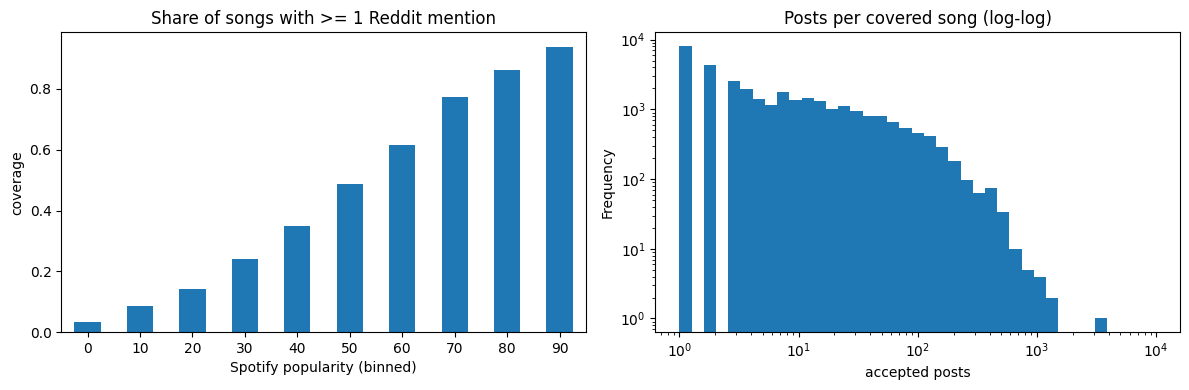

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# coverage rises steeply with popularity — a notability threshold
pop_bin = (songs["popularity"] // 10 * 10).astype(int)
cov_by_pop = covered.groupby(pop_bin).mean()
cov_by_pop.plot.bar(ax=axes[0], rot=0)
axes[0].set(title="Share of songs with >= 1 Reddit mention",
            xlabel="Spotify popularity (binned)", ylabel="coverage")

# mention counts are extremely heavy-tailed -> log scale
songs.loc[covered, "n_posts_full"].plot.hist(bins=np.logspace(0, 4, 40),
                                             ax=axes[1], log=True)
axes[1].set(xscale="log", title="Posts per covered song (log-log)",
            xlabel="accepted posts")
plt.tight_layout()

### 4.2 Do early Reddit mentions relate to eventual popularity?

Restrict to songs where the windowed features are meaningful: valid windows **and** released 2008–2018 (so the 365-day window is fully observed before the 2019-04-26 popularity snapshot and inside Reddit's lifetime).

analysis subset: 47,097 songs

Spearman correlations with 2019 popularity:
  n_posts_7d             rho = +0.245
  n_posts_30d            rho = +0.292
  n_posts_90d            rho = +0.330
  n_posts_365d           rho = +0.372
  total_score_365d       rho = +0.362
  n_communities_365d     rho = +0.368
  n_unique_users_365d    rho = +0.372


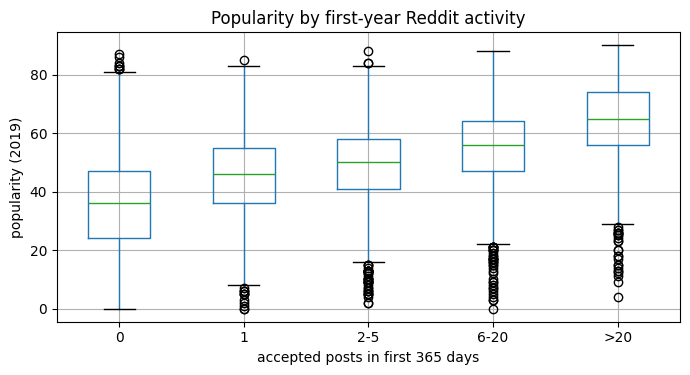

In [ ]:
sub = songs[songs["windows_valid"]].copy()
sub["release_date"] = pd.to_datetime(sub["release_date"], errors="coerce")
sub = sub[(sub["release_date"] >= "2008-01-01") & (sub["release_date"] <= "2018-04-26")]
print(f"analysis subset: {len(sub):,} songs")

sub["log_posts_365d"] = np.log1p(sub["n_posts_365d"].fillna(0))
print("\nSpearman correlations with 2019 popularity:")
for col in ["n_posts_7d", "n_posts_30d", "n_posts_90d", "n_posts_365d",
            "total_score_365d", "n_communities_365d", "n_unique_users_365d"]:
    rho = sub[col].fillna(0).corr(sub["popularity"], method="spearman")
    print(f"  {col:22s} rho = {rho:+.3f}")

sub["posts_365d_bin"] = pd.cut(
    sub["n_posts_365d"].fillna(0), [-0.1, 0, 1, 5, 20, 1e6],
    labels=["0", "1", "2-5", "6-20", ">20"])
ax = sub.boxplot(column="popularity", by="posts_365d_bin", figsize=(7, 4))
ax.set(xlabel="accepted posts in first 365 days", ylabel="popularity (2019)",
       title="Popularity by first-year Reddit activity")
plt.suptitle("")
plt.tight_layout()

### 4.3 Longevity shapes: attention trajectories (descriptive)

`decay_ratio_full` (late-period vs peak activity) and `persistence_full` (share of weeks with any mention) separate one-burst songs from evergreen ones. Remember these are **descriptive** — they use post-2019 data.

songs with >= 10 mentions: 10,942


,base_title,primary_artist,popularity,n_posts_full,persistence_full,decay_ratio_full
2224,Coming Down,Bon Iver,48.0,15.0,1.0,0.0000
2518,White Parents Are Gonna Hate This,SAINt JHN,60.0,10.0,1.0,0.0625
2523,25 Soldiers,Swizz Beatz,43.0,13.0,1.0,0.0000
3213,Different Game,Jackson Wang,47.0,12.0,1.0,0.0000
3422,Paper Doll,John Mayer,63.0,13.0,1.0,0.0000
3642,Subway Art,Tish Hyman,29.0,14.0,1.0,0.0000
6085,GTFO,Mariah Carey,59.0,23.0,1.0,0.0000
10816,Miss You,Eric Nam,59.0,15.0,1.0,0.0385
11596,Feels Like Summer,Weezer,62.0,20.0,1.0,0.0000
15243,Merrie Land,"The Good, the Bad & the Queen",50.0,20.0,1.0,0.0000


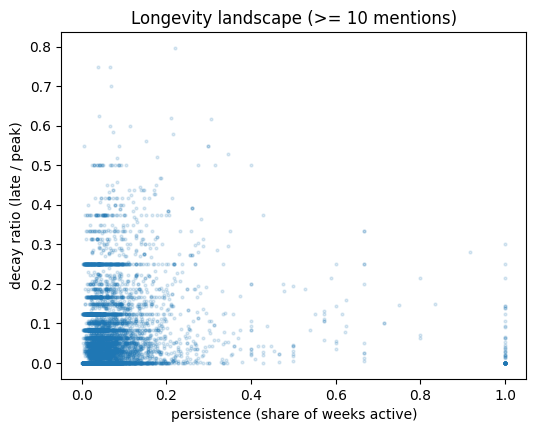

In [ ]:
traj = songs[covered & (songs["n_posts_full"] >= 10)]
print(f"songs with >= 10 mentions: {len(traj):,}")

ax = traj.plot.scatter("persistence_full", "decay_ratio_full", s=4, alpha=0.15,
                       figsize=(6, 4.5))
ax.set(title="Longevity landscape (>= 10 mentions)",
       xlabel="persistence (share of weeks active)",
       ylabel="decay ratio (late / peak)")

# most persistent songs
traj.nlargest(10, "persistence_full")[
    ["base_title", "primary_artist", "popularity",
     "n_posts_full", "persistence_full", "decay_ratio_full"]]

### 4.4 One song's mention timeline

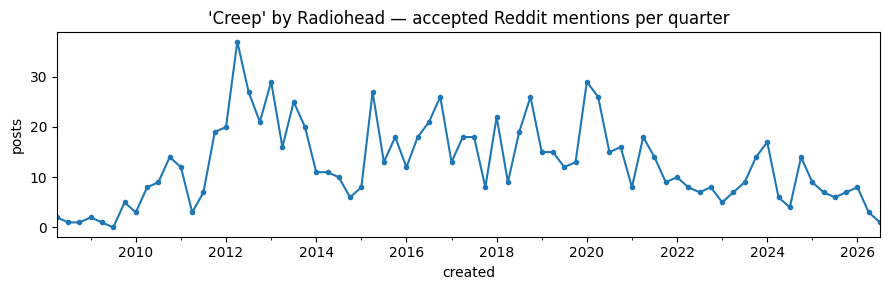

In [ ]:
timeline = posts_for_song(creep_id).set_index("created").resample("QE").size()
ax = timeline.plot(figsize=(9, 3), marker=".")
ax.set(title="'Creep' by Radiohead — accepted Reddit mentions per quarter",
       ylabel="posts")
plt.tight_layout()

## Caveats when interpreting anything above

- **Coverage bias**: mentions come from 15 major music subreddits, not all of Reddit.
- **Score snapshots**: archive `score`/`num_comments` were captured near post time — treat as lower bounds.
- **Precision ~93%** on accepted matches (audited); generic-titled songs are the riskiest slice.
- **Leakage rule**: only `*_7d/30d/90d/365d` features (with `windows_valid`) may be used to *predict* the 2019 popularity snapshot; `*_full` features are for describing longevity, not prediction.